In [1]:
import numpy as np  
import matplotlib.pyplot as plt 
import random
from random import sample
from scipy import stats
import emcee
import time
import math
import corner
import dynesty
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc

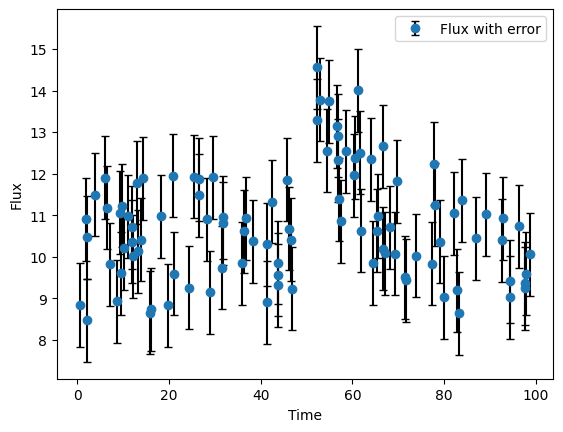

In [2]:
data=np.load("Transient.npy")
times=data[:,0]
flux=data[:,1]
err=data[:,2]
plt.errorbar(times, flux, yerr=err, fmt='o', ecolor='black', capsize=3, label='Flux with error')
plt.xlabel("Time")
plt.ylabel("Flux")
plt.legend()
plt.show()

In [7]:
# our third parameter is ln alpha 

def model(x):
    array=np.full_like(times,1)
    array[times<=x[0]]=x[1]
    array[times>x[0]]=x[1]+x[2]*np.exp(-np.exp(x[3])*(times[times>x[0]]-x[0])) 
    return array

def LogLikelihood(x):
   return  -0.5*np.sum(((flux-model(x))/err)**2+np.log(2*np.pi*err**2))

def prior_t0(x):
   return x[0]*100

def prior_A(x):
    return x[2]*50
    
def prior_b(x):
    return x[1]*50
    
def prior_lnalpha(x):
    return 5*(2*x[3]-1)
   
def prior(x):
    return [prior_t0(x),prior_b(x),prior_A(x),prior_lnalpha(x)]


In [8]:
sampler = dynesty.NestedSampler(LogLikelihood, prior, 4)
sampler.run_nested()
sresults = sampler.results

iter: 1 | bound: 0 | nc: 1 | ncall: 501 | eff(%):  0.200 | loglstar:   -inf < -173023.385 <    inf | logz: -173030.295 +/-  0.117 | dlogz:    inf >  0.509                                            

iter: 4036 | bound: 79 | nc: 604 | ncall: 76768 | eff(%):  5.257 | loglstar:   -inf < -178.444 <    inf | logz: -185.349 +/-  0.108 | dlogz: 33.630 >  0.509                                          /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
iter: 7763 | +500 | bound: 174 | nc: 1 | ncall: 148202 | eff(%):  5.594 | loglstar:   -inf < -140.654 <    inf | logz: -155.394 +/-  0.169 | dlogz:  0.001 >  0.509                                   

In [1]:
rfig, raxes = dyplot.runplot(sresults)
tfig, taxes = dyplot.traceplot(sresults)

NameError: name 'dyplot' is not defined

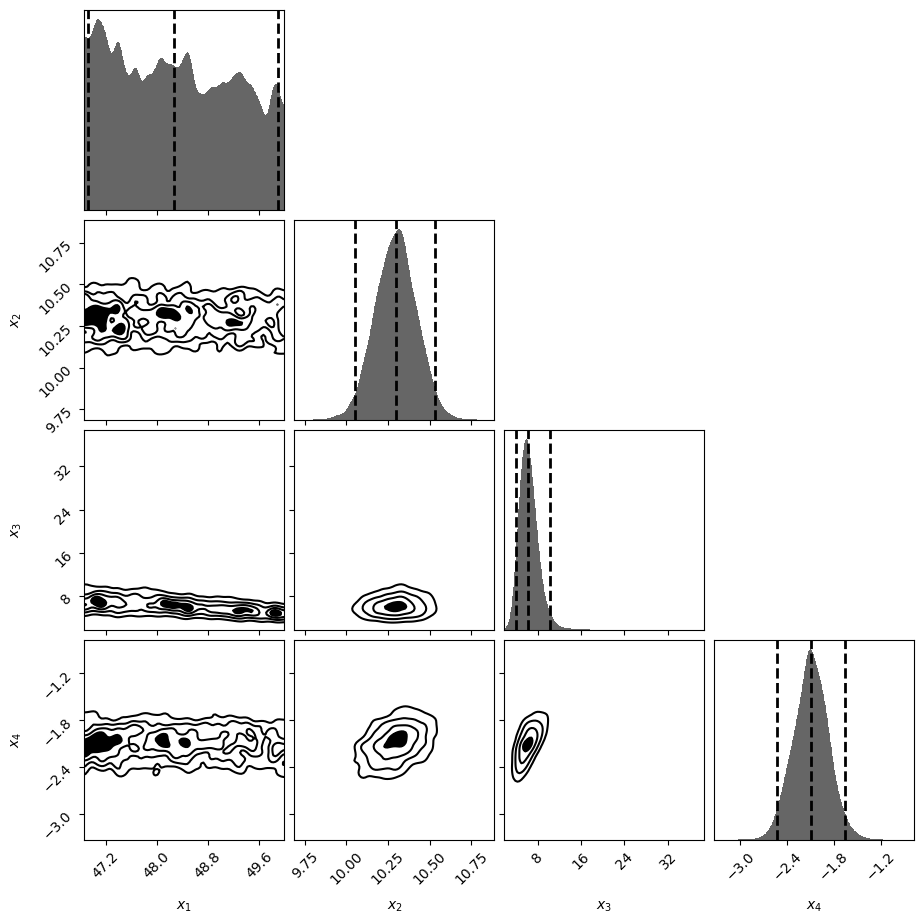

In [44]:
cfig, caxes = dyplot.cornerplot(sresults)

Bayesian evidence 4.219844845351102e-68
68% parameter credible regions are:
 [[47.276340882804675, 49.366516825460245], [10.164882264483953, 10.420075157366954], [4.873600801046288, 7.721895145822608], [-2.319731794578164, -1.8795704194094727]]

Mean and covariance of parameters are: [48.31180319 10.29478222  6.352081   -2.09575179]
[[ 0.79314116 -0.00338064 -0.67113246 -0.0030374 ]
 [-0.00338064  0.01563592  0.0213918   0.01078094]
 [-0.67113246  0.0213918   2.57732507  0.25407576]
 [-0.0030374   0.01078094  0.25407576  0.0491219 ]]


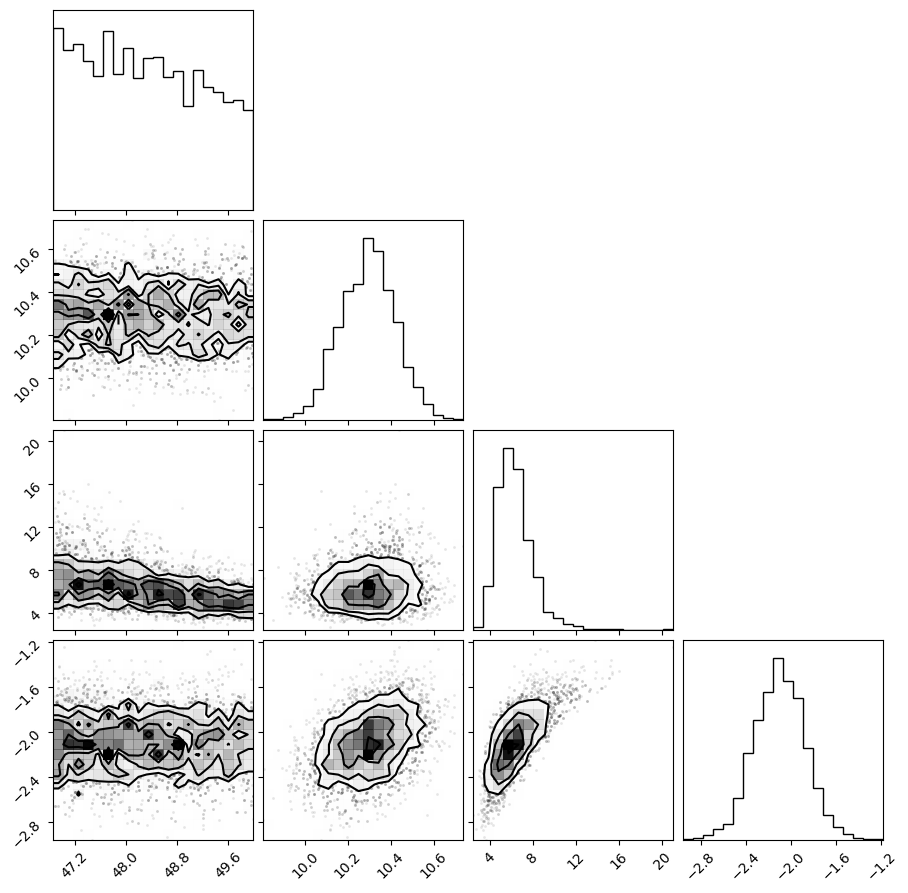

In [29]:
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights


evidence = sresults.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))

# Generate a new set of results with statistical+sampling uncertainties.
#results_sim = dyfunc.simulate_run(sresults)

samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal);

In [ ]:
def model2(x):
    return x[1]+x[2]*np.exp(-(times-x[0])**2/(2*(np.exp(x[3]))**2)) 
   
def LogLikelihood2(x):
   return  -0.5*np.sum(((flux-model2(x))/err)**2+np.log(2*np.pi*err**2))

def prior_lnsigma(x):
    return 5*(2*x[3]-1)
   
def prior2(x):
    return [prior_t0(x),prior_b(x),prior_A(x),prior_lnalpha(x)]

In [46]:
sampler2 = dynesty.NestedSampler(LogLikelihood2, prior2, 4)
sampler2.run_nested()
sresults2 = sampler2.results

iter: 3783 | bound: 33 | nc: 52 | ncall: 43024 | eff(%):  8.793 | loglstar:   -inf < -179.039 <    inf | logz: -185.772 +/-  0.110 | dlogz: 13.933 >  0.509                                           /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
iter: 3788 | bound: 34 | nc: 135 | ncall: 43597 | eff(%):  8.689 | loglstar:   -inf < -179.038 <    inf | logz: -185.768 +/-  0.110 | dlogz: 13.918 >  0.509                                          /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/dynesty/bounding.py:6

KeyboardInterrupt: 